In [22]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer

df = pd.read_csv("../data/base1_reviews/sentiment_labelled_sentences.csv")
df["target"] = (df["class"] == "positive").astype(int)

contagem_classes = df.groupby("target")["target"].count()
print(contagem_classes / contagem_classes.sum() * 100)

target
0    50.0
1    50.0
Name: target, dtype: float64


In [23]:
X = df["sentence"]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
print("Treinamento:", X_train.shape, " Teste:", X_test.shape)

validacao = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Treinamento: (2250,)  Teste: (750,)


In [24]:
from sklearn.naive_bayes import MultinomialNB

pipe_nb = Pipeline([
    ("tfidf", TfidfVectorizer(token_pattern=r"\b[A-Za-zÀ-ÿ]+\b")),
    ("clf", MultinomialNB()),
])

parametros_nb = {
    "tfidf__max_features": [300, 500, 1000, 1500, 2000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "clf__alpha": [0.1, 0.5, 1.0, 2.0],
    "tfidf__min_df": [1, 2, 5],
    "tfidf__max_df": [0.85, 0.9, 1.0],
    "tfidf__sublinear_tf": [True, False],
    "clf__fit_prior": [True, False],
}

busca_nb = RandomizedSearchCV(
    pipe_nb, parametros_nb, n_iter=15,
    scoring="f1", cv=validacao, random_state=42, n_jobs=-1,
)
busca_nb.fit(X_train, y_train)

print("Naive Bayes - melhores hiperparâmetros:", busca_nb.best_params_)
print("Naive Bayes - F1 médio na validação:", round(busca_nb.best_score_, 4))

Naive Bayes - melhores hiperparâmetros: {'tfidf__sublinear_tf': False, 'tfidf__ngram_range': (1, 1), 'tfidf__min_df': 1, 'tfidf__max_features': 2000, 'tfidf__max_df': 0.85, 'clf__fit_prior': False, 'clf__alpha': 0.5}
Naive Bayes - F1 médio na validação: 0.8101


In [25]:
from sklearn.linear_model import LogisticRegression

pipe_logreg = Pipeline([
    ("tfidf", TfidfVectorizer(token_pattern=r"\b[A-Za-zÀ-ÿ]+\b")),
    ("clf", LogisticRegression(max_iter=2000, random_state=42)),
])

parametros_logreg = {
    "tfidf__max_features": [300, 500, 1000, 1500, 2000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "clf__C": [0.1, 0.3, 1, 3, 10],
    "tfidf__min_df": [1, 2, 5],
    "tfidf__max_df": [0.85, 0.9, 1.0],
    "tfidf__sublinear_tf": [True, False],
}

busca_logreg = RandomizedSearchCV(
    pipe_logreg, parametros_logreg, n_iter=15,
    scoring="f1", cv=validacao, random_state=42, n_jobs=-1,
)
busca_logreg.fit(X_train, y_train)

print("Regressão Logística - melhores hiperparâmetros:", busca_logreg.best_params_)
print("Regressão Logística - F1 médio na validação:", round(busca_logreg.best_score_, 4))

Regressão Logística - melhores hiperparâmetros: {'tfidf__sublinear_tf': True, 'tfidf__ngram_range': (1, 1), 'tfidf__min_df': 1, 'tfidf__max_features': 2000, 'tfidf__max_df': 0.85, 'clf__C': 3}
Regressão Logística - F1 médio na validação: 0.8073


In [26]:
from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([
    ("tfidf", TfidfVectorizer(token_pattern=r"\b[A-Za-zÀ-ÿ]+\b")),
    ("clf", RandomForestClassifier(random_state=42, n_jobs=-1)),
])

parametros_rf = {
    "tfidf__max_features": [500, 1000, 2000],
    "tfidf__ngram_range": [(1, 1), (1, 2)],
    "clf__n_estimators": [200, 300, 500],
    "clf__max_depth": [None, 20, 30],
    "clf__min_samples_leaf": [1, 2, 4],
    "tfidf__min_df": [1, 2, 5],
    "tfidf__max_df": [0.85, 0.9, 1.0],
    "tfidf__sublinear_tf": [True, False],
}

busca_rf = RandomizedSearchCV(
    pipe_rf, parametros_rf, n_iter=35,
    scoring="f1", cv=validacao, random_state=42, n_jobs=-1,
)
busca_rf.fit(X_train, y_train)

print("Random Forest - melhores hiperparâmetros:", busca_rf.best_params_)
print("Random Forest - F1 médio na validação:", round(busca_rf.best_score_, 4))

Random Forest - melhores hiperparâmetros: {'tfidf__sublinear_tf': True, 'tfidf__ngram_range': (1, 1), 'tfidf__min_df': 1, 'tfidf__max_features': 2000, 'tfidf__max_df': 0.85, 'clf__n_estimators': 500, 'clf__min_samples_leaf': 2, 'clf__max_depth': None}
Random Forest - F1 médio na validação: 0.7664


In [27]:
resultados = {
    "Naive Bayes": busca_nb,
    "Regressão Logística": busca_logreg,
    "Random Forest": busca_rf,
}
for nome, busca in resultados.items():
    print(f"{nome:22s} F1 médio (validação) = {busca.best_score_:.4f}")

melhor_nome = max(resultados, key=lambda k: resultados[k].best_score_)
melhor_modelo = resultados[melhor_nome].best_estimator_
print(f"\nModelo selecionado: {melhor_nome}")

Naive Bayes            F1 médio (validação) = 0.8101
Regressão Logística    F1 médio (validação) = 0.8073
Random Forest          F1 médio (validação) = 0.7664

Modelo selecionado: Naive Bayes


Acurácia:  0.8107
Precisão:  0.8123
Recall:    0.8080
F1-score:  0.8102
AUC-ROC:             0.8926
AUC-PR (trapézio):   0.9002
Average Precision:   0.9003
Limiar de decisão utilizado nas métricas acima: 0.5 (padrão do .predict())


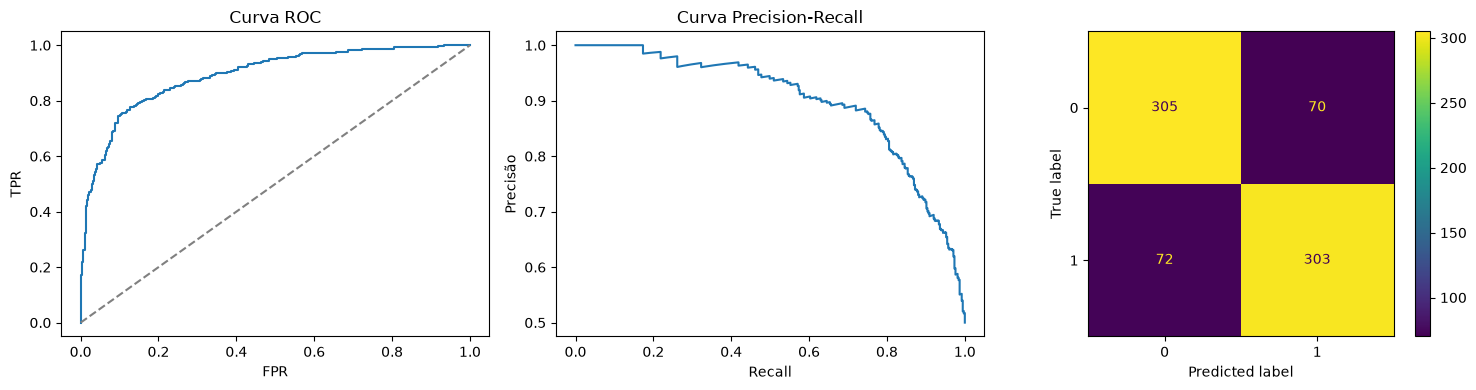

In [28]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, auc,
    average_precision_score, ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt

y_pred = melhor_modelo.predict(X_test)
y_prob = melhor_modelo.predict_proba(X_test)[:, 1]

print(f"Acurácia:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precisão:  {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")

fpr, tpr, _ = roc_curve(y_test, y_prob)
precisao_c, recall_c, _ = precision_recall_curve(y_test, y_prob)
auc_roc = roc_auc_score(y_test, y_prob)
auc_pr_trapezio = auc(recall_c, precisao_c)
average_precision = average_precision_score(y_test, y_prob)

print(f"AUC-ROC:             {auc_roc:.4f}")
print(f"AUC-PR (trapézio):   {auc_pr_trapezio:.4f}")
print(f"Average Precision:   {average_precision:.4f}")

print("Limiar de decisão utilizado nas métricas acima: 0.5 (padrão do .predict())")

fig, eixos = plt.subplots(1, 3, figsize=(15, 4))
eixos[0].plot(fpr, tpr); eixos[0].plot([0, 1], [0, 1], "--", color="gray")
eixos[0].set_title("Curva ROC"); eixos[0].set_xlabel("FPR"); eixos[0].set_ylabel("TPR")
eixos[1].plot(recall_c, precisao_c)
eixos[1].set_title("Curva Precision-Recall"); eixos[1].set_xlabel("Recall"); eixos[1].set_ylabel("Precisão")
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=eixos[2])
plt.tight_layout(); plt.show()

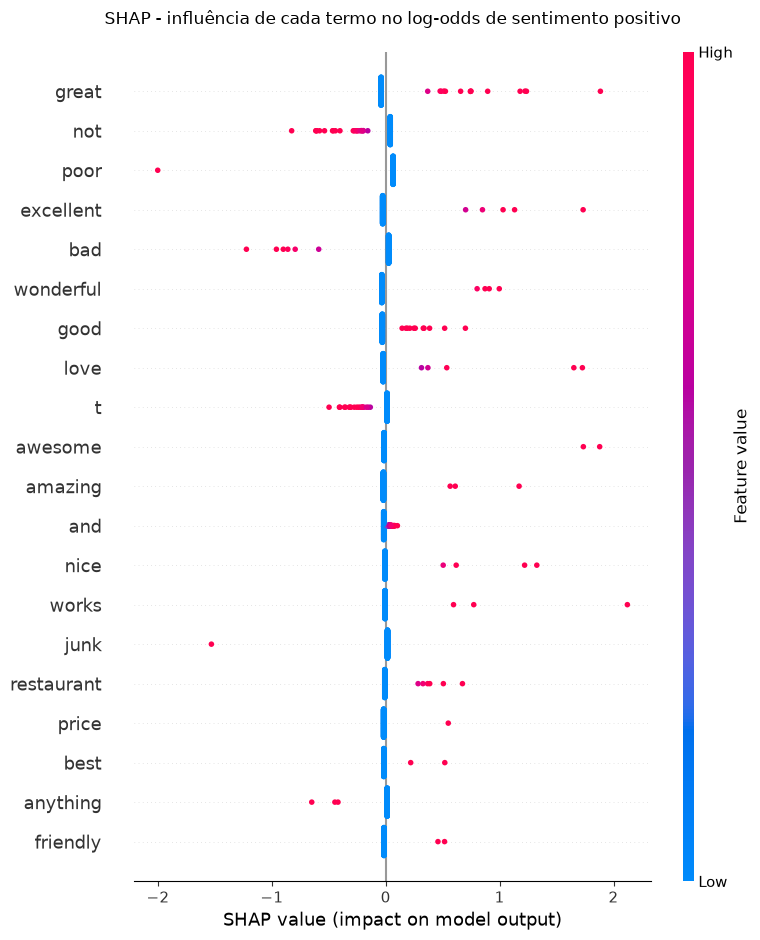

In [29]:
import shap

tfidf_ajustado = melhor_modelo.named_steps["tfidf"]
clf_ajustado = melhor_modelo.named_steps["clf"]
nomes_atributos = tfidf_ajustado.get_feature_names_out()

coeficientes = clf_ajustado.feature_log_prob_[1] - clf_ajustado.feature_log_prob_[0]
intercepto = clf_ajustado.class_log_prior_[1] - clf_ajustado.class_log_prior_[0]

X_train_tfidf = tfidf_ajustado.transform(X_train).toarray()
X_test_tfidf = tfidf_ajustado.transform(X_test).toarray()

rng = np.random.default_rng(42)
fundo = X_train_tfidf[rng.choice(X_train_tfidf.shape[0], size=100, replace=False)]
indices_shap = rng.choice(X_test_tfidf.shape[0], size=min(200, X_test_tfidf.shape[0]), replace=False)
X_shap = pd.DataFrame(X_test_tfidf[indices_shap], columns=nomes_atributos)

explainer = shap.LinearExplainer((coeficientes, intercepto), fundo)
valores_shap = explainer(X_shap)

shap.summary_plot(
    valores_shap.values, X_shap, feature_names=nomes_atributos,
    plot_type="dot", max_display=20, show=False,
)
plt.title("SHAP - influência de cada termo no log-odds de sentimento positivo", pad=20)
plt.tight_layout(); plt.show()

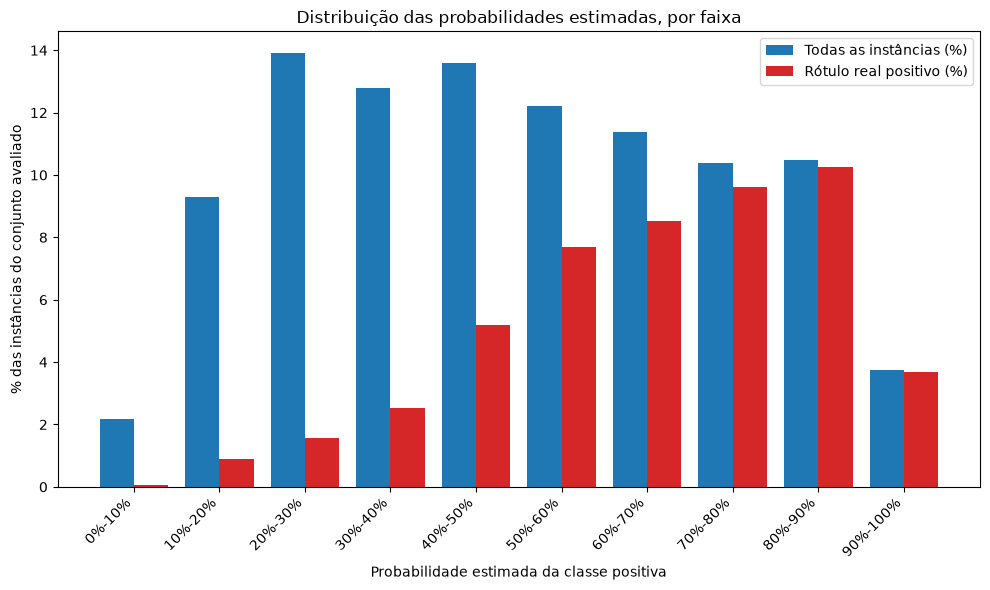

      faixa  qtd_total_por_faixa  pct_populacao_por_faixa  \
0    0%-10%                   49                 2.177778   
1   10%-20%                  209                 9.288889   
2   20%-30%                  313                13.911111   
3   30%-40%                  288                12.800000   
4   40%-50%                  306                13.600000   
5   50%-60%                  275                12.222222   
6   60%-70%                  256                11.377778   
7   70%-80%                  234                10.400000   
8   80%-90%                  236                10.488889   
9  90%-100%                   84                 3.733333   

   qtd_positivos_por_faixa  pct_positivos_na_faixa  
0                        1                2.040816  
1                       20                9.569378  
2                       35               11.182109  
3                       57               19.791667  
4                      117               38.235294  
5         

In [30]:
import sys
import os

sys.path.append(os.path.abspath("../.."))

from parte1_grafico_pontos_corte.histograma_grafico_e_faixas import gerar_grafico_e_metricas

proba_oof = cross_val_predict(melhor_modelo, X_train, y_train, cv=validacao, method="predict_proba")[:, 1]

fig, ax, tabela_validacao, _ = gerar_grafico_e_metricas(y_train.values, proba_oof, bin_width=10)
plt.show()
print(tabela_validacao)

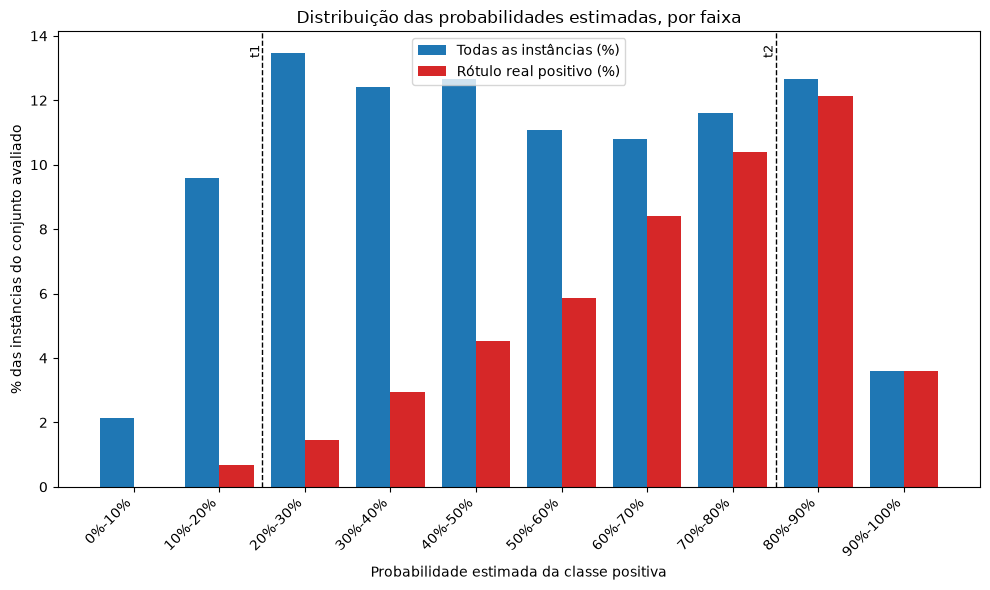

      faixa  qtd_total_por_faixa  pct_populacao_por_faixa  \
0    0%-10%                   16                 2.133333   
1   10%-20%                   72                 9.600000   
2   20%-30%                  101                13.466667   
3   30%-40%                   93                12.400000   
4   40%-50%                   95                12.666667   
5   50%-60%                   83                11.066667   
6   60%-70%                   81                10.800000   
7   70%-80%                   87                11.600000   
8   80%-90%                   95                12.666667   
9  90%-100%                   27                 3.600000   

   qtd_positivos_por_faixa  pct_positivos_na_faixa  
0                        0                0.000000  
1                        5                6.944444  
2                       11               10.891089  
3                       22               23.655914  
4                       34               35.789474  
5         

In [31]:
melhor_modelo.fit(X_train, y_train)
proba_teste = melhor_modelo.predict_proba(X_test)[:, 1]

fig, ax, tabela_teste, metricas = gerar_grafico_e_metricas(
    y_test.values, proba_teste, bin_width=10, t1=20, t2=80
)
plt.show()
print(tabela_teste)
print(metricas)